In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from itertools import combinations
from scipy.spatial.distance import pdist

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
print("Upload Adelaide_Data.csv")
uploaded = files.upload()

print("Upload Perth_Data.csv")
uploaded = files.upload()

print("Upload Sydney_Data.csv")
uploaded = files.upload()

print("Upload Tasmania_Data.csv")
uploaded = files.upload()


Upload Sydney_Data.csv


Saving Sydney_Data.csv to Sydney_Data.csv
Upload Perth_Data.csv


Saving Perth_Data.csv to Perth_Data.csv
Upload Adelaide_Data.csv


Saving Adelaide_Data.csv to Adelaide_Data.csv
Upload Tasmania_Data.csv


Saving Tasmania_Data.csv to Tasmania_Data.csv
Using dataset: Sydney
Dataset shape: (72000, 49)


In [ ]:
# LOAD DATASET
adelaide_df = pd.read_csv("Adelaide_Data.csv", header=None)
adelaide_df.head()

adelaide_df.shape

columns = (
    [f"X{i}" for i in range(1, 17)] +
    [f"Y{i}" for i in range(1, 17)] +
    [f"P{i}" for i in range(1, 17)] +
    ["Powerall"]
)

adelaide_df.columns = columns
print(adelaide_df.columns)

adelaide_df.head()

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6',
       'Y7', 'Y8', 'Y9', 'Y10', 'Y11', 'Y12', 'Y13', 'Y14', 'Y15', 'Y16', 'P1',
       'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12',
       'P13', 'P14', 'P15', 'P16', 'Powerall'],
      dtype='object')


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,P8,P9,P10,P11,P12,P13,P14,P15,P16,Powerall
0,316.5855,223.9277,182.3434,551.5497,7.8641,243.1339,361.0877,115.9284,78.6087,468.3799,...,82322.0277,98069.1011,86578.6330,93016.4133,63145.1829,98353.1952,80225.1390,98447.2846,97570.2225,1370374.145
1,530.3136,68.7031,31.5983,175.2582,516.1441,63.4652,67.0954,369.4486,14.0930,375.4462,...,83920.1033,80968.0044,87108.1328,68065.1856,99061.3812,77549.1426,99013.1628,78234.4337,84633.6493,1340929.765
2,27.3967,399.0488,565.6854,394.0466,120.2245,558.1293,546.4520,27.3256,314.1051,235.9476,...,97358.7395,93437.7170,69940.2554,92864.1192,60887.8095,72306.6556,81151.1515,83030.9726,94779.6131,1352031.511
3,346.1526,59.6375,226.2742,280.9095,402.2161,218.7181,207.0407,339.5676,0.0000,0.0000,...,80399.3841,89349.6141,85048.3860,70038.2271,92797.3569,97653.8121,74903.3740,71690.6549,96220.4768,1396754.375
4,317.9144,551.8542,335.4745,40.0240,316.6285,365.6434,416.3060,562.1028,211.3577,143.1255,...,97088.1761,81187.3982,63591.6729,92418.1977,82454.8256,97091.7749,85937.5437,66823.1572,93683.0996,1355708.577


In [ ]:
# INPUT AND OUTPUT COLUMNS
position_cols = [f"X{i}" for i in range(1, 17)] + [f"Y{i}" for i in range(1, 17)]
power_cols = [f"P{i}" for i in range(1, 17)]
target_col = "Powerall"

X = adelaide_df[position_cols + power_cols].copy()
y = adelaide_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (71999, 48)
y shape: (71999,)


In [ ]:
# MISSING VALUES
adelaide_df[position_cols + power_cols + [target_col]].isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0
X10,0


In [ ]:
# DISTANCE FEATURES
x_coords = adelaide_df[[f"X{i}" for i in range(1, 17)]].values
y_coords = adelaide_df[[f"Y{i}" for i in range(1, 17)]].values
coords = np.stack((x_coords, y_coords), axis=2)

pairs = list(combinations(range(1, 17), 2))
distance_cols = [f"D_{i}_{j}" for i, j in pairs]
distance_values = np.array([pdist(sample, metric="euclidean") for sample in coords])
distance_df = pd.DataFrame(distance_values, columns=distance_cols)

X = pd.concat([X.reset_index(drop=True), distance_df.reset_index(drop=True)], axis=1)
print("X shape after distance features:", X.shape)

X shape after distance features: (71999, 168)


In [ ]:
# SPLIT INTO TRAINING AND TESTING DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 57599
Testing samples: 14400


In [ ]:
# TRAIN THE RIDGE REGRESSION MODEL
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [ ]:
# PREDICT THE MODEL
y_pred = ridge_model.predict(X_test)

In [ ]:
# EVALUATE USING MAE, RMSE AND R2
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Ridge MAE:", mae)
print("Ridge RMSE:", rmse)
print("Ridge R2:", r2)

Ridge MAE: 5.7379674499705855
Ridge RMSE: 26.30710222157522
Ridge R2: 0.9999997804759204


In [ ]:
# HYPERPARAMETER TUNING
param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
  }

grid_search = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ]),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'ridge__alpha': 0.01}


In [ ]:
# EVALUATE TUNED MODEL
best_ridge = grid_search.best_estimator_
y_pred_tuned = best_ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Ridge MAE:", mae)
print("Tuned Ridge RMSE:", rmse)
print("Tuned Ridge R2:", r2)


Tuned Ridge MAE: 5.912108420587448
Tuned Ridge RMSE: 26.334454195402138
Tuned Ridge R2: 0.9999997800191968


In [ ]:
# CROSS VALIDATION
cv_scores = cross_val_score(
    best_ridge,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_rmse = np.sqrt(-cv_scores)
print("Cross-Validation RMSE Scores:", cv_rmse)
print("Average CV RMSE:", cv_rmse.mean())

Cross-Validation RMSE Scores: [ 10.92984075  11.9273458    9.07122684  12.0779915  186.25663082]
Average CV RMSE: 46.05260714254297


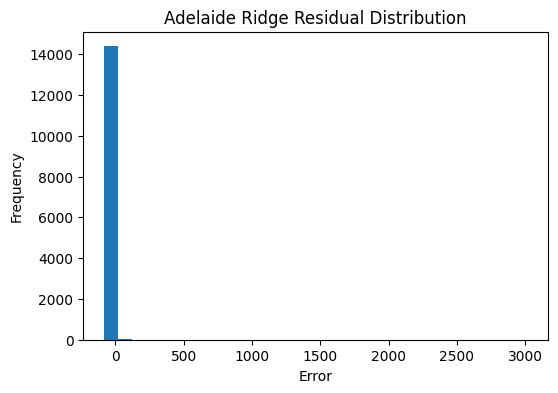

In [ ]:
# ERROR ANALYSIS (RESIDUAL DISTRIBUTION)
residuals = y_test - y_pred_tuned

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Adelaide Ridge Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

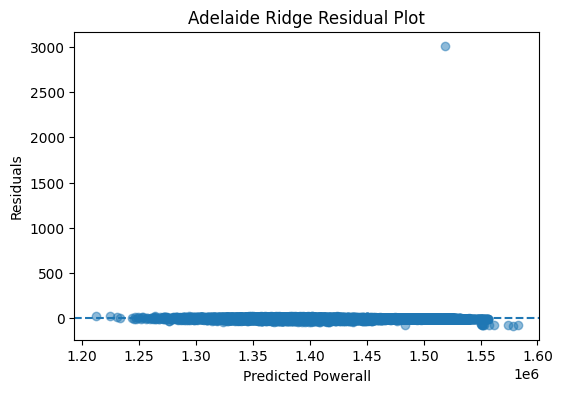

In [ ]:
# RESIDUAL PLOT
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_tuned, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Adelaide Ridge Residual Plot")
plt.xlabel("Predicted Powerall")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# TRAIN THE LASSO REGRESSION MODEL
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, max_iter=20000))
])

lasso_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1, max_iter=20000))])

In [ ]:
# PREDICT THE MODEL
y_pred = lasso_model.predict(X_test)

In [ ]:
# EVALUATE USING MAE, RMSE AND R2
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Lasso MAE:", mae)
print("Lasso RMSE:", rmse)
print("Lasso R2:", r2)

Lasso MAE: 5.993651779786596
Lasso RMSE: 26.437583273856873
Lasso R2: 0.9999997782928773


In [ ]:
# HYPERPARAMETER TUNING
param_grid = {
    "lasso__alpha": [0.001, 0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(max_iter=20000))
    ]),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'lasso__alpha': 1}


In [ ]:
# EVALUATE TUNED MODEL
best_lasso = grid_search.best_estimator_
y_pred_tuned = best_lasso.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Lasso MAE:", mae)
print("Tuned Lasso RMSE:", rmse)
print("Tuned Lasso R2:", r2)

Tuned Lasso MAE: 1.9982531918149389
Tuned Lasso RMSE: 25.88708608270819
Tuned Lasso R2: 0.9999997874297536


In [ ]:
# CROSS VALIDATION
cv_scores = cross_val_score(
    best_lasso,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_rmse = np.sqrt(-cv_scores)
print("Cross-Validation RMSE Scores:", cv_rmse)
print("Average CV RMSE:", cv_rmse.mean())

Cross-Validation RMSE Scores: [  3.41715088   2.5455874    2.37118095   2.78277187 186.37985336]
Average CV RMSE: 39.49930889269753


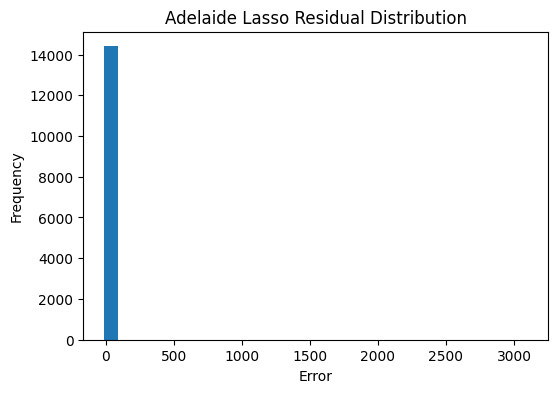

In [ ]:
# ERROR ANALYSIS (RESIDUAL DISTRIBUTION)
residuals = y_test - y_pred_tuned

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Adelaide Lasso Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

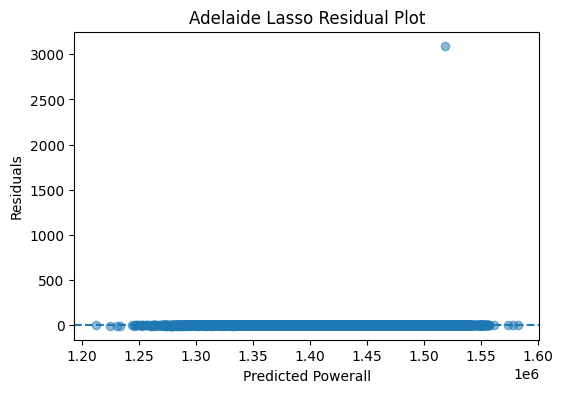

In [ ]:
# RESIDUAL PLOT
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_tuned, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Adelaide Lasso Residual Plot")
plt.xlabel("Predicted Powerall")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# ==================== PERTH DATASET ====================
# LOAD DATASET
perth_df = pd.read_csv("Perth_Data.csv", header=None)
perth_df.head()

perth_df.shape

perth_df.columns = columns
print(perth_df.columns)

perth_df.head()

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6',
       'Y7', 'Y8', 'Y9', 'Y10', 'Y11', 'Y12', 'Y13', 'Y14', 'Y15', 'Y16', 'P1',
       'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12',
       'P13', 'P14', 'P15', 'P16', 'Powerall'],
      dtype='object')


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,P8,P9,P10,P11,P12,P13,P14,P15,P16,Powerall
0,427.0737,155.1636,476.0661,5.7677,255.5230,410.5835,516.3158,47.4719,75.7125,463.0522,...,100328.8932,79696.1132,90093.0925,79395.6995,100893.8537,91116.6415,98560.6700,99789.2341,78199.7899,1480707.346
1,427.4820,147.4593,474.9960,9.5407,258.2593,404.2589,524.3422,44.4009,70.4385,468.8828,...,98879.6861,82893.9171,89158.6518,80356.5067,100927.1007,89760.5631,97828.2206,99214.7876,79108.3094,1479133.940
2,423.7709,155.9451,470.8182,4.0438,253.8868,390.2231,509.0224,50.7996,72.8076,463.4203,...,100504.0370,81572.7820,89932.3496,80588.3130,100977.1693,90274.1347,97757.2251,99333.6857,79691.2458,1475814.243
3,431.8288,146.6720,466.1145,7.0164,261.3787,408.9941,521.9852,44.0360,77.5854,450.5736,...,99857.6062,82267.0302,88657.7954,79139.2437,100480.0554,91102.1702,98224.0435,100672.3076,78387.9296,1484052.684
4,437.7897,141.3579,474.3819,4.3434,256.5644,393.0113,516.1617,52.4880,66.1179,457.0365,...,99953.9882,80579.2854,88819.3409,80145.6969,100693.3759,89663.6079,97947.9575,100924.1871,80104.7240,1479350.362


In [ ]:
# INPUT AND OUTPUT COLUMNS
X = perth_df[position_cols + power_cols].copy()
y = perth_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (72000, 48)
y shape: (72000,)


In [ ]:
# MISSING VALUES
perth_df[position_cols + power_cols + [target_col]].isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0
X10,0


In [ ]:
# DISTANCE FEATURES
x_coords = perth_df[[f"X{i}" for i in range(1, 17)]].values
y_coords = perth_df[[f"Y{i}" for i in range(1, 17)]].values
coords = np.stack((x_coords, y_coords), axis=2)

distance_values = np.array([pdist(sample, metric="euclidean") for sample in coords])
distance_df = pd.DataFrame(distance_values, columns=distance_cols)

X = pd.concat([X.reset_index(drop=True), distance_df.reset_index(drop=True)], axis=1)
print("X shape after distance features:", X.shape)

X shape after distance features: (72000, 168)


In [ ]:
# SPLIT INTO TRAINING AND TESTING DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 57600
Testing samples: 14400


In [ ]:
# TRAIN THE RIDGE REGRESSION MODEL
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
ridge_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [ ]:
# PREDICT THE MODEL
y_pred = ridge_model.predict(X_test)

In [ ]:
# EVALUATE USING MAE, RMSE AND R2
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Ridge MAE:", mae)
print("Ridge RMSE:", rmse)
print("Ridge R2:", r2)

Ridge MAE: 0.5969966357868624
Ridge RMSE: 0.7559290219470243
Ridge R2: 0.9999999997871057


In [ ]:
# HYPERPARAMETER TUNING
param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ]),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'ridge__alpha': 0.01}


In [ ]:
# EVALUATE TUNED MODEL
best_ridge = grid_search.best_estimator_
y_pred_tuned = best_ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Ridge MAE:", mae)
print("Tuned Ridge RMSE:", rmse)
print("Tuned Ridge R2:", r2)

Tuned Ridge MAE: 0.005974651391621188
Tuned Ridge RMSE: 0.007565715923288163
Tuned Ridge R2: 0.9999999999999787


In [ ]:
# CROSS VALIDATION
cv_scores = cross_val_score(
    best_ridge,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_rmse = np.sqrt(-cv_scores)
print("Cross-Validation RMSE Scores:", cv_rmse)
print("Average CV RMSE:", cv_rmse.mean())

Cross-Validation RMSE Scores: [0.01664108 0.01595666 0.01503716 0.00845134 0.00844536]
Average CV RMSE: 0.012906320636825347


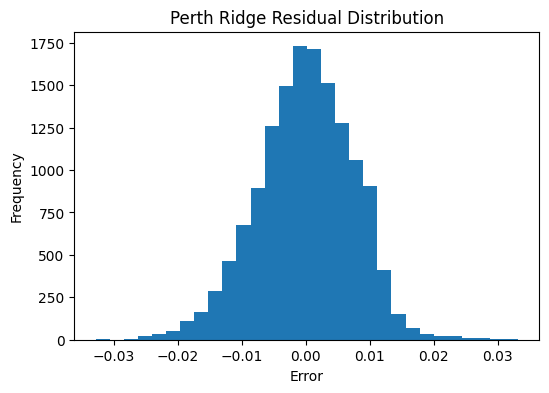

In [ ]:
# ERROR ANALYSIS (RESIDUAL DISTRIBUTION)
residuals = y_test - y_pred_tuned

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Perth Ridge Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

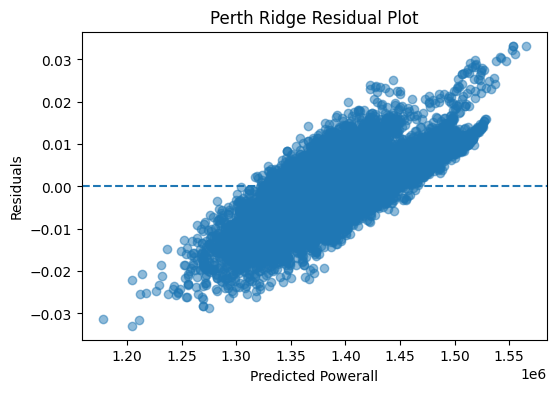

In [ ]:
# RESIDUAL PLOT
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_tuned, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Perth Ridge Residual Plot")
plt.xlabel("Predicted Powerall")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# TRAIN THE LASSO REGRESSION MODEL
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, max_iter=20000))
])

lasso_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1, max_iter=20000))])

In [ ]:
# PREDICT THE MODEL
y_pred = lasso_model.predict(X_test)

In [ ]:
# EVALUATE USING MAE, RMSE AND R2
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Lasso MAE:", mae)
print("Lasso RMSE:", rmse)
print("Lasso R2:", r2)

Lasso MAE: 1.7534403180159441
Lasso RMSE: 2.2484786830149197
Lasso R2: 0.99999999811644


In [ ]:
# HYPERPARAMETER TUNING
param_grid = {
    "lasso__alpha": [0.001, 0.01, 0.1, 1, 10]
    }

grid_search = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(max_iter=20000))
    ]),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'lasso__alpha': 0.1}


In [ ]:
# EVALUATE TUNED MODEL
best_lasso = grid_search.best_estimator_
y_pred_tuned = best_lasso.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Lasso MAE:", mae)
print("Tuned Lasso RMSE:", rmse)
print("Tuned Lasso R2:", r2)


Tuned Lasso MAE: 1.7534403180159441
Tuned Lasso RMSE: 2.2484786830149197
Tuned Lasso R2: 0.99999999811644


In [ ]:
# CROSS VALIDATION
cv_scores = cross_val_score(
    best_lasso,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_rmse = np.sqrt(-cv_scores)
print("Cross-Validation RMSE Scores:", cv_rmse)
print("Average CV RMSE:", cv_rmse.mean())

Cross-Validation RMSE Scores: [2.55542721 1.61613096 3.56790777 6.20624193 5.62475297]
Average CV RMSE: 3.9140921663935773


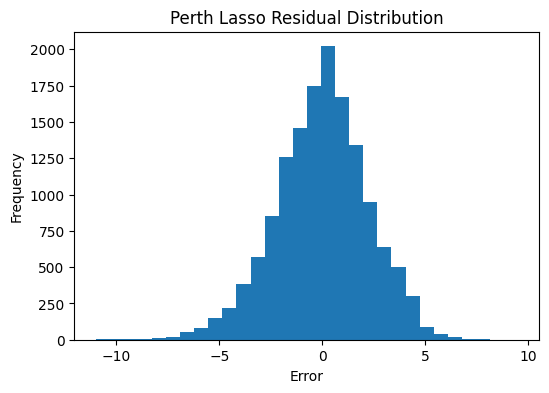

In [ ]:
# ERROR ANALYSIS (RESIDUAL DISTRIBUTION)
residuals = y_test - y_pred_tuned

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Perth Lasso Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

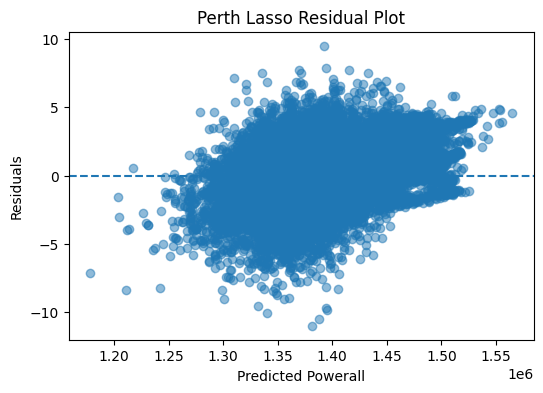

In [ ]:
# RESIDUAL PLOT
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_tuned, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Perth Lasso Residual Plot")
plt.xlabel("Predicted Powerall")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# ==================== SYDNEY DATASET ====================
# LOAD DATASET
sydney_df = pd.read_csv("Sydney_Data.csv", header=None)
sydney_df.head()

sydney_df.shape

sydney_df.columns = columns
print(sydney_df.columns)

sydney_df.head()

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6',
       'Y7', 'Y8', 'Y9', 'Y10', 'Y11', 'Y12', 'Y13', 'Y14', 'Y15', 'Y16', 'P1',
       'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12',
       'P13', 'P14', 'P15', 'P16', 'Powerall'],
      dtype='object')


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,P8,P9,P10,P11,P12,P13,P14,P15,P16,Powerall
0,127.9439,264.9656,68.3481,521.7570,443.6997,195.9648,166.7701,504.2850,104.0226,205.2257,...,92861.7375,84584.2549,89041.0312,87204.4296,97380.7385,94753.7880,81677.9764,103129.6938,97196.8128,1463622.174
1,500.4677,278.6497,47.4062,417.3653,551.7083,401.1797,0.0000,161.7773,368.1543,45.9850,...,83029.8436,91483.7433,93748.1139,99467.6415,95935.6597,84254.7876,93786.3095,94499.4790,88941.7152,1489888.502
2,511.7510,104.4383,566.0000,380.4079,345.8587,0.0000,90.5588,7.2899,566.0000,566.0000,...,91309.1752,107598.5159,101897.2685,100876.0477,79350.0981,100060.2964,92733.9494,100646.9126,83394.8729,1495035.934
3,19.6990,216.4378,355.2960,67.8151,518.7256,72.1572,222.7933,223.9242,566.0000,312.4474,...,92083.6042,103182.5412,80688.8463,92306.4190,106440.6778,102118.7041,99295.1266,96503.3818,77942.2947,1459841.498
4,0.0000,0.0000,243.3420,0.0000,566.0000,0.0000,198.4878,0.0000,566.0000,566.0000,...,85602.1738,98370.5585,97148.3728,95775.0777,80723.5930,95865.7812,88525.7698,94546.5417,85021.1027,1475765.923


In [ ]:
# INPUT AND OUTPUT COLUMNS
X = sydney_df[position_cols + power_cols].copy()
y = sydney_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (72000, 48)
y shape: (72000,)


In [ ]:
# MISSING VALUES
sydney_df[position_cols + power_cols + [target_col]].isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0
X10,0


In [ ]:
# DISTANCE FEATURES
x_coords = sydney_df[[f"X{i}" for i in range(1, 17)]].values
y_coords = sydney_df[[f"Y{i}" for i in range(1, 17)]].values
coords = np.stack((x_coords, y_coords), axis=2)

distance_values = np.array([pdist(sample, metric="euclidean") for sample in coords])
distance_df = pd.DataFrame(distance_values, columns=distance_cols)

X = pd.concat([X.reset_index(drop=True), distance_df.reset_index(drop=True)], axis=1)
print("X shape after distance features:", X.shape)

X shape after distance features: (72000, 168)


In [ ]:
# SPLIT INTO TRAINING AND TESTING DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 57600
Testing samples: 14400


In [ ]:
# TRAIN THE RIDGE REGRESSION MODEL
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [ ]:
# PREDICT THE MODEL
y_pred = ridge_model.predict(X_test)

In [ ]:
# EVALUATE USING MAE, RMSE AND R2
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Ridge MAE:", mae)
print("Ridge RMSE:", rmse)
print("Ridge R2:", r2)

Ridge MAE: 2.0213120585843636
Ridge RMSE: 18.325435953943895
Ridge R2: 0.9999993688063261


In [ ]:
# HYPERPARAMETER TUNING
param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ]),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'ridge__alpha': 0.01}


In [ ]:
# EVALUATE TUNED MODEL
best_ridge = grid_search.best_estimator_
y_pred_tuned = best_ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Ridge MAE:", mae)
print("Tuned Ridge RMSE:", rmse)
print("Tuned Ridge R2:", r2)

Tuned Ridge MAE: 1.9107238925673462
Tuned Ridge RMSE: 18.27912184515429
Tuned Ridge R2: 0.9999993719927421


In [ ]:
# CROSS VALIDATION
cv_scores = cross_val_score(
    best_ridge,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_rmse = np.sqrt(-cv_scores)
print("Cross-Validation RMSE Scores:", cv_rmse)
print("Average CV RMSE:", cv_rmse.mean())


Cross-Validation RMSE Scores: [ 2.38995228  2.93385676 60.22077408  2.51470666  3.82355066]
Average CV RMSE: 14.376568089332869


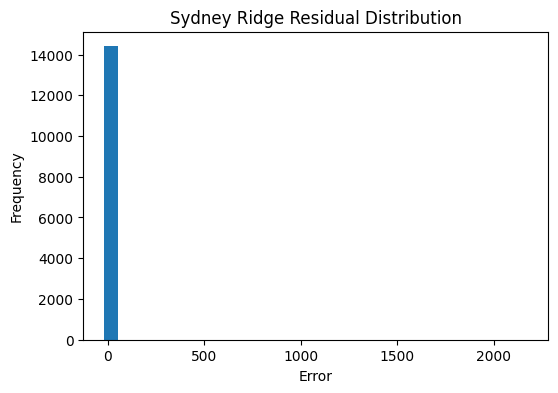

In [ ]:
# ERROR ANALYSIS (RESIDUAL DISTRIBUTION)
residuals = y_test - y_pred_tuned

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Sydney Ridge Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

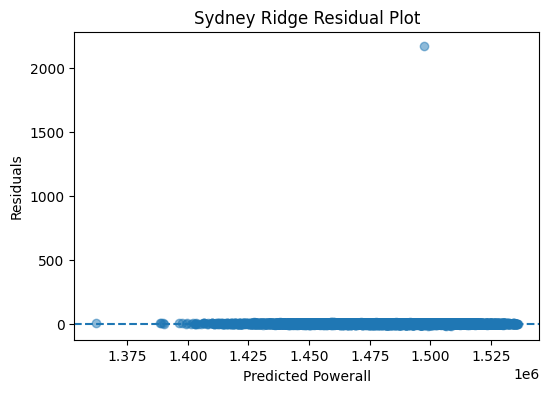

In [ ]:
# RESIDUAL PLOT
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_tuned, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Sydney Ridge Residual Plot")
plt.xlabel("Predicted Powerall")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# TRAIN THE LASSO REGRESSION MODEL
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, max_iter=20000))
])

lasso_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1, max_iter=20000))])

In [ ]:
# PREDICT THE MODEL
y_pred = lasso_model.predict(X_test)

In [ ]:
# EVALUATE USING MAE, RMSE AND R2
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Lasso MAE:", mae)
print("Lasso RMSE:", rmse)
print("Lasso R2:", r2)


In [ ]:
# HYPERPARAMETER TUNING
param_grid = {
    "lasso__alpha": [0.001, 0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(max_iter=20000))
    ]),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

In [ ]:
# EVALUATE TUNED MODEL
best_lasso = grid_search.best_estimator_
y_pred_tuned = best_lasso.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Lasso MAE:", mae)
print("Tuned Lasso RMSE:", rmse)
print("Tuned Lasso R2:", r2)

In [ ]:
# CROSS VALIDATION
cv_scores = cross_val_score(
    best_lasso,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_rmse = np.sqrt(-cv_scores)
print("Cross-Validation RMSE Scores:", cv_rmse)
print("Average CV RMSE:", cv_rmse.mean())

In [ ]:
# ERROR ANALYSIS (RESIDUAL DISTRIBUTION)
residuals = y_test - y_pred_tuned

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Sydney Lasso Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# RESIDUAL PLOT
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_tuned, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Sydney Lasso Residual Plot")
plt.xlabel("Predicted Powerall")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# ==================== TASMANIA DATASET ====================
# LOAD DATASET
tasmania_df = pd.read_csv("Tasmania_Data.csv", header=None)
tasmania_df.head()

tasmania_df.shape

tasmania_df.columns = columns
print(tasmania_df.columns)

tasmania_df.head()

In [ ]:
# INPUT AND OUTPUT COLUMNS
X = tasmania_df[position_cols + power_cols].copy()
y = tasmania_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
# MISSING VALUES
tasmania_df[position_cols + power_cols + [target_col]].isnull().sum()

In [ ]:
# DISTANCE FEATURES
x_coords = tasmania_df[[f"X{i}" for i in range(1, 17)]].values
y_coords = tasmania_df[[f"Y{i}" for i in range(1, 17)]].values
coords = np.stack((x_coords, y_coords), axis=2)

distance_values = np.array([pdist(sample, metric="euclidean") for sample in coords])
distance_df = pd.DataFrame(distance_values, columns=distance_cols)

X = pd.concat([X.reset_index(drop=True), distance_df.reset_index(drop=True)], axis=1)
print("X shape after distance features:", X.shape)

In [ ]:
# SPLIT INTO TRAINING AND TESTING DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

In [ ]:
# TRAIN THE RIDGE REGRESSION MODEL
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

In [ ]:
# PREDICT THE MODEL
y_pred = ridge_model.predict(X_test)

In [ ]:
# EVALUATE USING MAE, RMSE AND R2
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Ridge MAE:", mae)
print("Ridge RMSE:", rmse)
print("Ridge R2:", r2)

In [ ]:
# HYPERPARAMETER TUNING
param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ]),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

In [ ]:
# EVALUATE TUNED MODEL
best_ridge = grid_search.best_estimator_
y_pred_tuned = best_ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Ridge MAE:", mae)
print("Tuned Ridge RMSE:", rmse)
print("Tuned Ridge R2:", r2)

In [ ]:
# CROSS VALIDATION
cv_scores = cross_val_score(
    best_ridge,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_rmse = np.sqrt(-cv_scores)
print("Cross-Validation RMSE Scores:", cv_rmse)
print("Average CV RMSE:", cv_rmse.mean())

In [ ]:
# ERROR ANALYSIS (RESIDUAL DISTRIBUTION)
residuals = y_test - y_pred_tuned

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Tasmania Ridge Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# RESIDUAL PLOT
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_tuned, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Tasmania Ridge Residual Plot")
plt.xlabel("Predicted Powerall")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# TRAIN THE LASSO REGRESSION MODEL
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, max_iter=20000))
])

lasso_model.fit(X_train, y_train

In [ ]:
# PREDICT THE MODEL
y_pred = lasso_model.predict(X_test)

In [ ]:
# EVALUATE USING MAE, RMSE AND R2
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Lasso MAE:", mae)
print("Lasso RMSE:", rmse)
print("Lasso R2:", r2)

In [ ]:
# HYPERPARAMETER TUNING
param_grid = {
    "lasso__alpha": [0.001, 0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(max_iter=20000))
    ]),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

In [ ]:
# EVALUATE TUNED MODEL
best_lasso = grid_search.best_estimator_
y_pred_tuned = best_lasso.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Lasso MAE:", mae)
print("Tuned Lasso RMSE:", rmse)
print("Tuned Lasso R2:", r2)

In [ ]:
# CROSS VALIDATION
cv_scores = cross_val_score(
    best_lasso,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_rmse = np.sqrt(-cv_scores)
print("Cross-Validation RMSE Scores:", cv_rmse)
print("Average CV RMSE:", cv_rmse.mean())

In [ ]:
# ERROR ANALYSIS (RESIDUAL DISTRIBUTION)
residuals = y_test - y_pred_tuned

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Tasmania Lasso Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# RESIDUAL PLOT
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_tuned, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Tasmania Lasso Residual Plot")
plt.xlabel("Predicted Powerall")
plt.ylabel("Residuals")
plt.show()
